# Задание 4 — Графовые ядра (Graph Kernels)

реализуем
- **Shortest Path Kernel**
- **Weisfeiler-Lehman Kernel**

**Датасет:** [PROTEINS](https://chrsmrrs.github.io/datasets/docs/datasets/) — 1113 графов белков.
Вершина — элемент вторичной структуры (α-спираль / β-лист / виток), её метка — тип этого
элемента; ребро соединяет вершины, соседние в аминокислотной последовательности или
близкие в 3D. Бинарная метка графа (по соглашению датасета) — **фермент / не фермент**.


In [1]:
import numpy as np
import networkx as nx
from collections import Counter
from pathlib import Path

from sklearn.svm import SVC
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold,
    RepeatedStratifiedKFold, cross_val_score,
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve, auc,
)

import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

## 1. Датасет

PROTEINS распространяется в текстовом формате [TU Dortmund](https://chrsmrrs.github.io/datasets/docs/format/).
Все графы лежат «вперемешку» в нескольких файлах:

- `PROTEINS_A.txt` — список рёбер (глобальные id вершин, нумерация с 1);
- `PROTEINS_graph_indicator.txt` — к какому графу принадлежит каждая вершина;
- `PROTEINS_graph_labels.txt` — метка каждого графа (1 / 2);
- `PROTEINS_node_labels.txt` — метка (тип вторичной структуры) каждой вершины.


In [2]:
import os, zipfile, urllib.request

def ensure_tu_dataset(name, root="."):
    target = os.path.join(root, name)
    if os.path.isdir(target):
        print(f"{name}: установлено")
        return
    url = f"https://www.chrsmrrs.com/graphkerneldatasets/{name}.zip"
    zpath = os.path.join(root, f"{name}.zip")
    print(f"Скачиваю {name} ...")
    urllib.request.urlretrieve(url, zpath)
    with zipfile.ZipFile(zpath) as z:
        z.extractall(root)
    os.remove(zpath)
    print(f"{name}: готов")

ensure_tu_dataset("PROTEINS")

PROTEINS: установлено


In [ ]:
def load_tu_dataset(root, name):
    root = Path(root)
    rd = lambda suffix: (root / f"{name}_{suffix}.txt")

    node_to_graph = np.loadtxt(rd("graph_indicator"), dtype=int)   # вершина -> номер графа
    graph_labels  = np.loadtxt(rd("graph_labels"),    dtype=int)
    node_labels   = np.loadtxt(rd("node_labels"),     dtype=int)
    edges         = np.loadtxt(rd("A"), dtype=int, delimiter=",")

    graphs = [nx.Graph() for _ in range(graph_labels.shape[0])]

    for node_id, g_id in enumerate(node_to_graph, start=1):
        graphs[g_id - 1].add_node(node_id, label=int(node_labels[node_id - 1]))

    for u, v in edges:
        g_id = node_to_graph[u - 1]
        graphs[g_id - 1].add_edge(int(u), int(v))

    return graphs, graph_labels


graphs, y_raw = load_tu_dataset("PROTEINS", "PROTEINS")
# приводим метки 1/2 -> 1/0
y = (y_raw == 1).astype(int)
DATASET_NAME = "PROTEINS"

print(f"Загружен {DATASET_NAME}: {len(graphs)} графов")
print(f"Классы: {dict(Counter(y))}  (1 — метка 1 датасета, 0 — метка 2)")
print(f"Пример графа: {graphs[0].number_of_nodes()} вершин, "
      f"{graphs[0].number_of_edges()} рёбер, "
      f"типы вершин: {sorted(set(nx.get_node_attributes(graphs[0], 'label').values()))}")

Загружен PROTEINS: 1113 графов
Классы: {np.int64(1): 663, np.int64(0): 450}  (1 — метка 1 датасета, 0 — метка 2)
Пример графа: 42 вершин, 81 рёбер, типы вершин: [0, 1]


## 2. Разведочный анализ данных (EDA)



**Базовая статистика датасета PROTEINS:**

| показатель | значение |
|---|---|
| Графов | 1113 |
| Вершин (min / avg / max) | 4 / 39.1 / 620 |
| Рёбер (min / avg / max) | 5 / 72.8 / 1049 |
| Средняя степень | 3.73 |
| Диаметр (min / avg / max) | 1 / 11.6 / 64 |
| Связных графов | 1067 / 1113 |
| Доля класса 1 | 59.6% |

Графы PROTEINS разнятся по размеру сильно (от 4 до 620 вершин), и часть из них несвязна (1067 из 1113)
это может быть важно тк связность компонент влияет на работу SP

И есть смещение в сторону класса 1 - поэтому в целом если пикать первый класс то точность бинарной классификации будет почти 60%



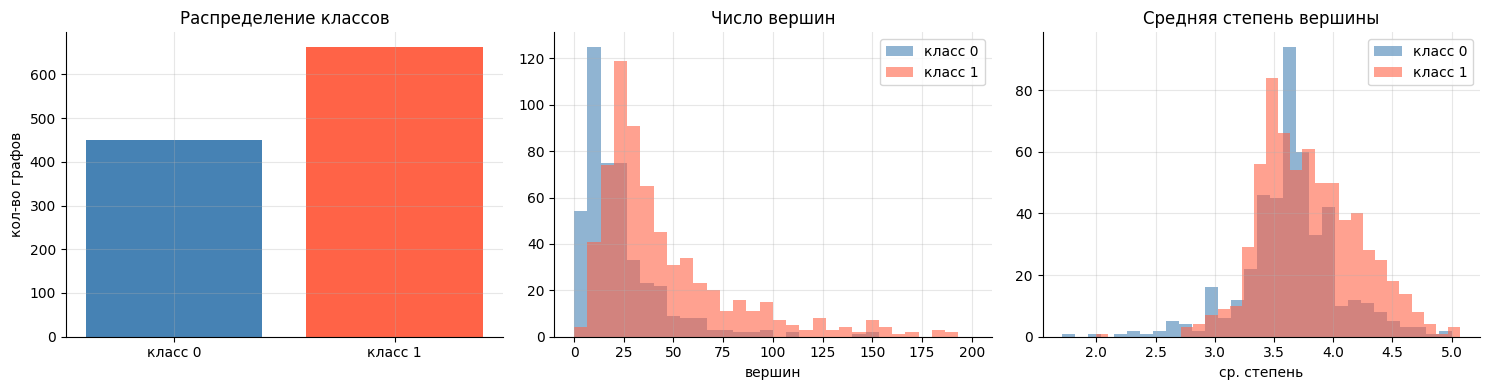

In [ ]:
# величины для графиков ниже
n_nodes = np.array([G.number_of_nodes() for G in graphs])
avg_deg = np.array([2 * G.number_of_edges() / max(G.number_of_nodes(), 1) for G in graphs])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(["класс 0", "класс 1"],
            [int((y == 0).sum()), int((y == 1).sum())], color=["steelblue", "tomato"])
axes[0].set_title("Распределение классов"); axes[0].set_ylabel("кол-во графов")

for cls, color, lbl in [(0, "steelblue", "класс 0"), (1, "tomato", "класс 1")]:
    axes[1].hist(n_nodes[y == cls], bins=30, alpha=0.6, color=color, label=lbl, range=(0, 200))
axes[1].set_title("Число вершин"); axes[1].set_xlabel("вершин"); axes[1].legend()

for cls, color, lbl in [(0, "steelblue", "класс 0"), (1, "tomato", "класс 1")]:
    axes[2].hist(avg_deg[y == cls], bins=30, alpha=0.6, color=color, label=lbl)
axes[2].set_title("Средняя степень вершины"); axes[2].set_xlabel("ср. степень"); axes[2].legend()

plt.tight_layout(); plt.show()

**Что видно по распределениям:**
- число вершин у классов сильно перекрывается, хотя у класса 1 хвост в сторону крупных
  графов длиннее — слабый сигнал, но не разделяющий признак;
- средняя степень у обоих классов схожа (≈3.5–4) — графы разреженные;


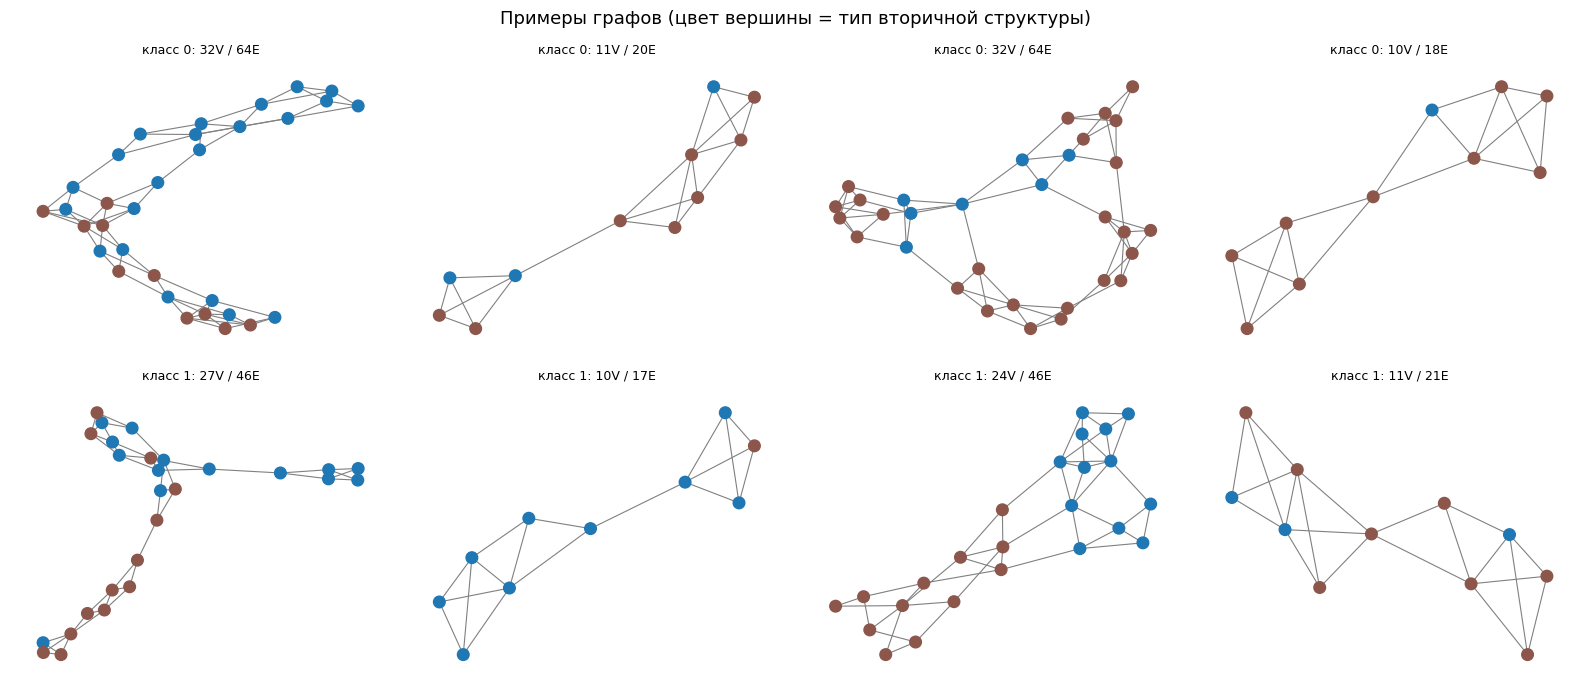

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("Примеры графов (цвет вершины = тип вторичной структуры)", fontsize=13)

for cls, row_axes, title in [(0, axes[0], "класс 0"), (1, axes[1], "класс 1")]:
    # берём не самые гигантские графы, чтобы рисунок читался
    cls_idx = [i for i in range(len(graphs)) if y[i] == cls and graphs[i].number_of_nodes() <= 40][:4]
    for ax, idx in zip(row_axes, cls_idx):
        G = graphs[idx]
        pos = nx.spring_layout(G, seed=0)
        node_colors = [G.nodes[v]["label"] for v in G.nodes()]
        nx.draw(G, pos, ax=ax, node_size=70, node_color=node_colors,
                cmap="tab10", vmin=0, vmax=2, edge_color="gray", width=0.8)
        ax.set_title(f"{title}: {G.number_of_nodes()}V / {G.number_of_edges()}E", fontsize=9)

plt.tight_layout(); plt.show()

## 3. Shortest Path Kernel


In [ ]:
def _cosine_normalize(train_vecs, test_vecs):
    train_vecs = np.asarray(train_vecs, dtype=np.float64)
    test_vecs = np.asarray(test_vecs, dtype=np.float64).reshape(-1, train_vecs.shape[1])

    tr_norm = np.sqrt((train_vecs ** 2).sum(axis=1)); tr_norm[tr_norm == 0] = 1.0
    K_train = (train_vecs @ train_vecs.T) / np.outer(tr_norm, tr_norm)

    if test_vecs.shape[0] == 0:
        return K_train, np.zeros((0, train_vecs.shape[0]))
    te_norm = np.sqrt((test_vecs ** 2).sum(axis=1)); te_norm[te_norm == 0] = 1.0
    K_test = (test_vecs @ train_vecs.T) / np.outer(te_norm, tr_norm)
    return K_train, K_test


def graph_to_sp_vector(G, max_len):
    counts = np.zeros(max_len + 1, dtype=np.float64)
    for src, lengths in nx.shortest_path_length(G):
        for tgt, d in lengths.items():
            if tgt > src and 1 <= d <= max_len:
                counts[d] += 1.0
    return counts


def shortest_path_kernel(train_graphs, test_graphs):
    all_graphs = list(train_graphs) + list(test_graphs)

    max_len = 0
    for G in all_graphs:
        for _, lengths in nx.shortest_path_length(G):
            if lengths:
                max_len = max(max_len, max(lengths.values()))

    train_vecs = np.array([graph_to_sp_vector(G, max_len) for G in train_graphs])
    test_vecs  = np.array([graph_to_sp_vector(G, max_len) for G in test_graphs])
    return _cosine_normalize(train_vecs, test_vecs)



SP-вектор path_graph(5): [0 4 3 2 1]
Проверка пройдена ✓


## 4. Обучение SVC и подбор гиперпараметров

Делим данные на train/test со стратификацией (классы несбалансированы 663/450),
считаем ядровые матрицы и подбираем `C` по 5-fold кросс-валидации.

In [7]:
idx_all = np.arange(len(graphs))
idx_train, idx_test, y_train, y_test = train_test_split(
    idx_all, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
train_graphs = [graphs[i] for i in idx_train]
test_graphs  = [graphs[i] for i in idx_test]

print(f"train: {len(train_graphs)} графов  |  test: {len(test_graphs)} графов")
print(f"train классы: {dict(Counter(y_train))}  |  test классы: {dict(Counter(y_test))}")

K_train_sp, K_test_sp = shortest_path_kernel(train_graphs, test_graphs)
print(f"\nK_train: {K_train_sp.shape},  K_test: {K_test_sp.shape}")

train: 834 графов  |  test: 279 графов
train классы: {np.int64(0): 337, np.int64(1): 497}  |  test классы: {np.int64(1): 166, np.int64(0): 113}



K_train: (834, 834),  K_test: (279, 834)


In [ ]:
param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


grid_sp = GridSearchCV(SVC(kernel="precomputed", class_weight="balanced"),
                       param_grid, cv=cv, scoring="f1", n_jobs=-1, refit=True)
grid_sp.fit(K_train_sp, y_train)

print(f"Лучший C:        {grid_sp.best_params_['C']}")
print(f"Лучший f1 (CV):  {grid_sp.best_score_:.3f}")
best_sp = grid_sp.best_estimator_

Лучший C:        0.01
Лучший f1 (CV):  0.790


## 5. Метрики качества

In [9]:
def evaluate(model, K_test, y_test, name="модель"):
    y_pred  = model.predict(K_test)
    y_score = model.decision_function(K_test)

    m = {
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall":    recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1":        f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "roc_auc":   roc_auc_score(y_test, y_score),
    }
    print(f"\n{'─'*46}\n  {name}\n{'─'*46}")
    for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
        print(f"  {k:<11}{m[k]:.3f}")
    print(f"\n{classification_report(y_test, y_pred, zero_division=0)}")
    return y_pred, y_score, m


y_pred_sp, y_score_sp, metrics_sp = evaluate(best_sp, K_test_sp, y_test, "SP kernel + SVC")


──────────────────────────────────────────────
  SP kernel + SVC
──────────────────────────────────────────────
  accuracy   0.688
  precision  0.709
  recall     0.688
  f1         0.691
  roc_auc    0.765

              precision    recall  f1-score   support

           0       0.59      0.74      0.66       113
           1       0.79      0.65      0.71       166

    accuracy                           0.69       279
   macro avg       0.69      0.70      0.69       279
weighted avg       0.71      0.69      0.69       279



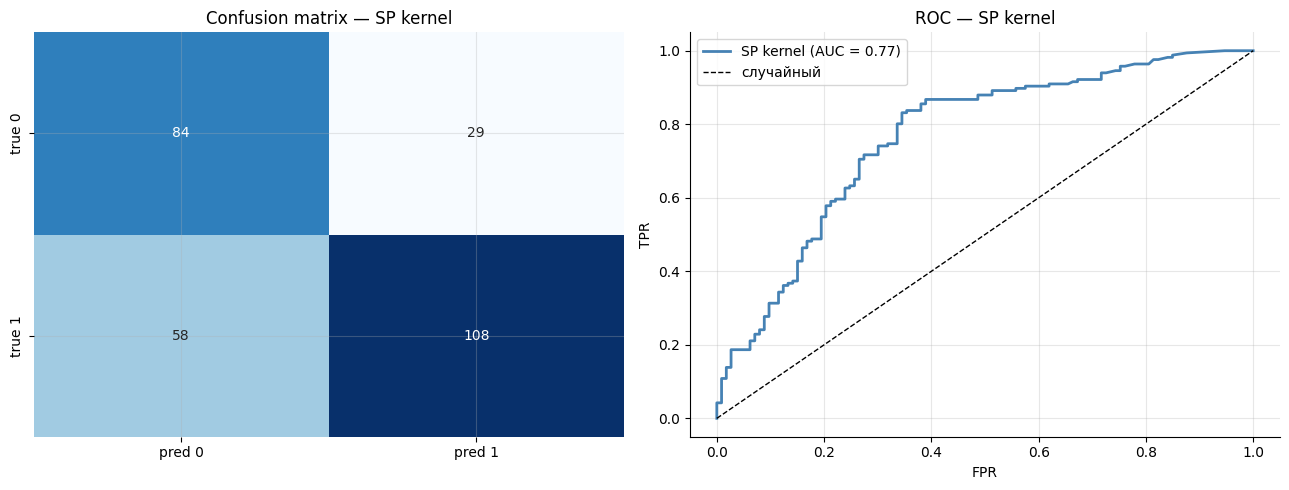

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred_sp)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False,
            xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
axes[0].set_title("Confusion matrix — SP kernel")

fpr, tpr, _ = roc_curve(y_test, y_score_sp)
axes[1].plot(fpr, tpr, color="steelblue", lw=2, label=f"SP kernel (AUC = {auc(fpr, tpr):.2f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="случайный")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ROC — SP kernel"); axes[1].legend()

plt.tight_layout(); plt.show()

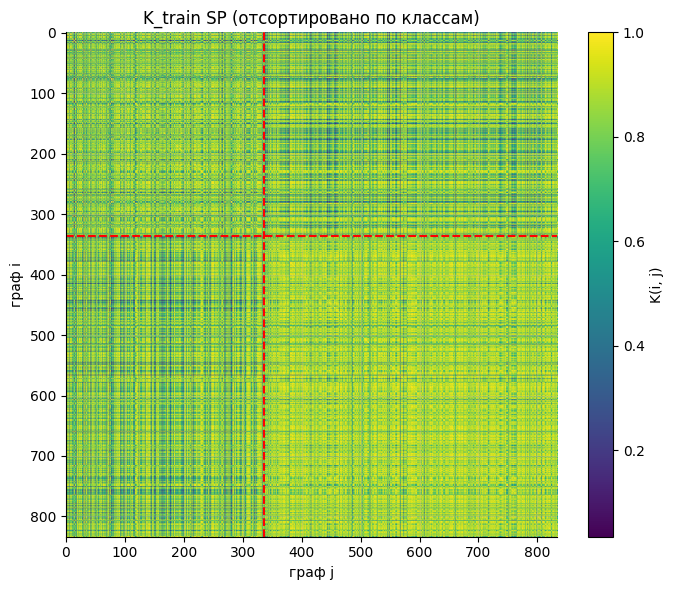

In [11]:
# матрица ядра, отсортированная по классам: ищем блочную структуру
order = np.argsort(y_train)
K_vis = K_train_sp[np.ix_(order, order)]

plt.figure(figsize=(7, 6))
plt.imshow(K_vis, cmap="viridis", aspect="auto")
plt.colorbar(label="K(i, j)")
n0 = int((y_train == 0).sum())
plt.axhline(n0 - 0.5, color="red", lw=1.5, ls="--")
plt.axvline(n0 - 0.5, color="red", lw=1.5, ls="--")
plt.title("K_train SP (отсортировано по классам)")
plt.xlabel("граф j"); plt.ylabel("граф i")
plt.tight_layout(); plt.show()

Если бы ядро хорошо различало классы, мы бы увидели
два ярких квадрата на диагонали (графы одного класса похожи друг на друга) и тёмный фон
между ними. Здесь же квадраты едва заметны — значит SP-ядро разделяет классы лишь слабо.

SP смотрит только на то, насколько далеко вершины друг от друга, но не
смотрит что это за вершины. А у белков тип элемента (спираль / лист / виток) как раз важен.

## 6. Weisfeiler-Lehman Kernel


In [ ]:
def wl_kernel(train_graphs, test_graphs, h=4):
    all_graphs = list(train_graphs) + list(test_graphs)
    n_train = len(train_graphs)

    def init_labels(G):
        attr = nx.get_node_attributes(G, "label")
        return dict(attr) if attr else {v: G.degree(v) for v in G.nodes()}

    label_dicts = [init_labels(G) for G in all_graphs]
    feature_counters = [Counter() for _ in all_graphs]

    # уровень h=0: исходные метки
    for fc, (G, ld) in zip(feature_counters, zip(all_graphs, label_dicts)):
        for v in G.nodes():
            fc[("h0", ld[v])] += 1

    # уровни h=1..H
    for it in range(1, h + 1):
        sig_to_id = {}                  
        new_label_dicts = []
        for G, ld in zip(all_graphs, label_dicts):
            new_ld = {}
            for v in G.nodes():
                sig = (ld[v], tuple(sorted(ld[u] for u in G.neighbors(v))))
                new_ld[v] = sig_to_id.setdefault(sig, len(sig_to_id))
            new_label_dicts.append(new_ld)
        for fc, (G, nld) in zip(feature_counters, zip(all_graphs, new_label_dicts)):
            for v in G.nodes():
                fc[(f"h{it}", nld[v])] += 1
        label_dicts = new_label_dicts

    all_keys = sorted(set().union(*[fc.keys() for fc in feature_counters]), key=str)
    key_idx = {k: i for i, k in enumerate(all_keys)}

    def to_vec(fc):
        v = np.zeros(len(all_keys), dtype=np.float64)
        for k, c in fc.items():
            v[key_idx[k]] = c
        return v

    vecs = np.array([to_vec(fc) for fc in feature_counters])
    train_vecs, test_vecs = vecs[:n_train], vecs[n_train:]
    wl_kernel.last_dim = vecs.shape[1]   # для справки: размерность WL-вектора
    return _cosine_normalize(train_vecs, test_vecs)


K_train_wl, K_test_wl = wl_kernel(train_graphs, test_graphs, h=4)
print(f"K_train: {K_train_wl.shape},  K_test: {K_test_wl.shape}")
print(f"Размерность WL-вектора (уникальных поддеревьев за h=0..4): {wl_kernel.last_dim}")

K_train: (834, 834),  K_test: (279, 834)
Размерность WL-вектора (уникальных поддеревьев за h=0..4): 94878


In [13]:
grid_wl = GridSearchCV(SVC(kernel="precomputed", class_weight="balanced"),
                       param_grid, cv=cv, scoring="f1", n_jobs=-1, refit=True)
grid_wl.fit(K_train_wl, y_train)

print(f"Лучший C:       {grid_wl.best_params_['C']}")
print(f"Лучший f1 (CV): {grid_wl.best_score_:.3f}")
best_wl = grid_wl.best_estimator_

y_pred_wl, y_score_wl, metrics_wl = evaluate(best_wl, K_test_wl, y_test, "WL kernel + SVC")

Лучший C:       1
Лучший f1 (CV): 0.811

──────────────────────────────────────────────
  WL kernel + SVC
──────────────────────────────────────────────
  accuracy   0.738
  precision  0.744
  recall     0.738
  f1         0.740
  roc_auc    0.806

              precision    recall  f1-score   support

           0       0.66      0.73      0.69       113
           1       0.80      0.75      0.77       166

    accuracy                           0.74       279
   macro avg       0.73      0.74      0.73       279
weighted avg       0.74      0.74      0.74       279



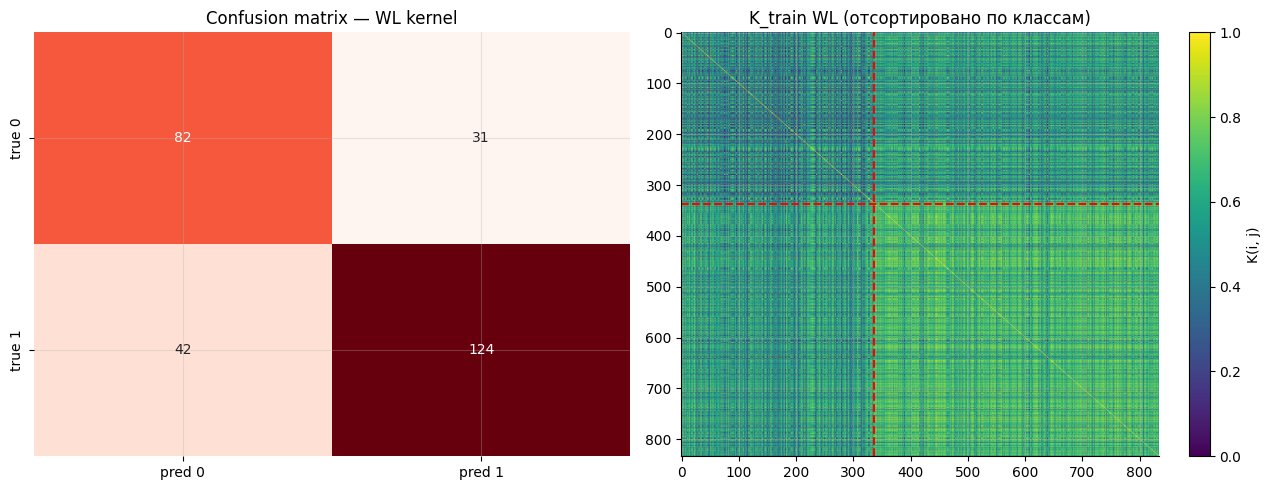

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred_wl)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", ax=axes[0], cbar=False,
            xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
axes[0].set_title("Confusion matrix — WL kernel")

order = np.argsort(y_train)
K_vis = K_train_wl[np.ix_(order, order)]
im = axes[1].imshow(K_vis, cmap="viridis", aspect="auto")
plt.colorbar(im, ax=axes[1], label="K(i, j)")
n0 = int((y_train == 0).sum())
axes[1].axhline(n0 - 0.5, color="red", lw=1.5, ls="--")
axes[1].axvline(n0 - 0.5, color="red", lw=1.5, ls="--")
axes[1].set_title("K_train WL (отсортировано по классам)")

plt.tight_layout(); plt.show()

Здесь два квадрата на диагонали видны чётче, чемсу SP: графы одного класса в среднем заметно похожи друг на друга, а фон между классамистемнее. 
Так выходит потому, что WL смотрит не только на расстояния между вершинами, но и
на их типы (спираль / лист / виток) и на то, кто с кем соседствует. 

Белки с похожей укладкой получают близкие описания — поэтому и метрики у WL выше.

## 7. Сравнение ядер

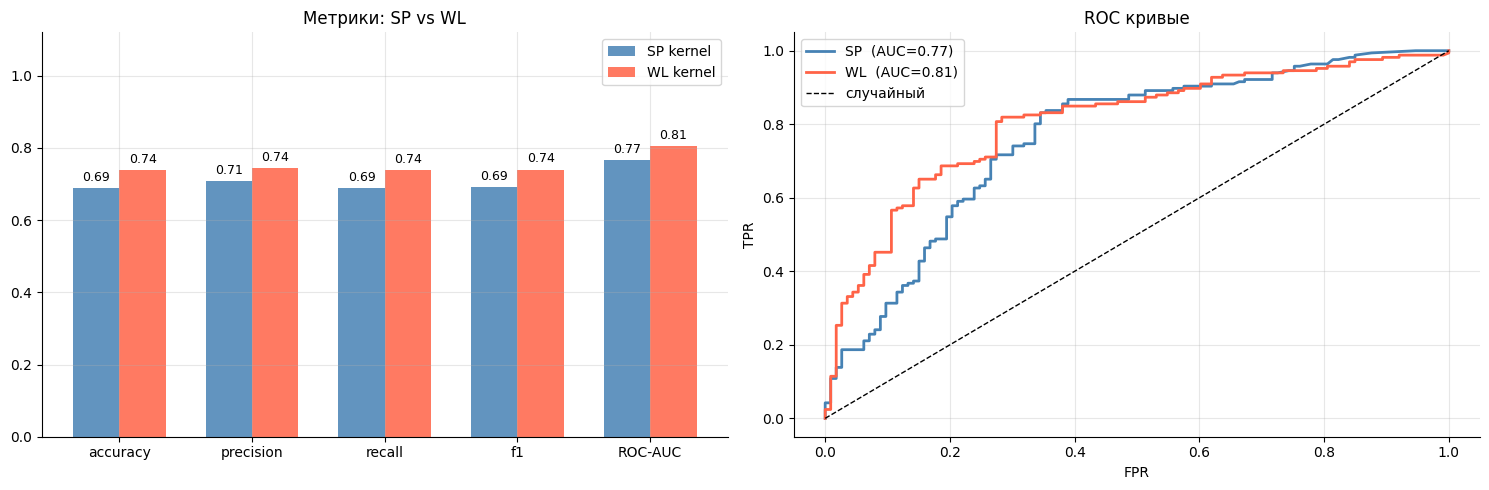

In [15]:
metric_names = ["accuracy", "precision", "recall", "f1", "roc_auc"]
labels_ru = ["accuracy", "precision", "recall", "f1", "ROC-AUC"]
sp_vals = [metrics_sp[m] for m in metric_names]
wl_vals = [metrics_wl[m] for m in metric_names]

x = np.arange(len(metric_names)); width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

b1 = axes[0].bar(x - width/2, sp_vals, width, label="SP kernel", color="steelblue", alpha=0.85)
b2 = axes[0].bar(x + width/2, wl_vals, width, label="WL kernel", color="tomato", alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_ru)
axes[0].set_ylim(0, 1.12); axes[0].set_title("Метрики: SP vs WL"); axes[0].legend()
for b in list(b1) + list(b2):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
                 f"{b.get_height():.2f}", ha="center", fontsize=9)

fpr_sp, tpr_sp, _ = roc_curve(y_test, y_score_sp)
fpr_wl, tpr_wl, _ = roc_curve(y_test, y_score_wl)
axes[1].plot(fpr_sp, tpr_sp, color="steelblue", lw=2, label=f"SP  (AUC={auc(fpr_sp, tpr_sp):.2f})")
axes[1].plot(fpr_wl, tpr_wl, color="tomato",    lw=2, label=f"WL  (AUC={auc(fpr_wl, tpr_wl):.2f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="случайный")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].set_title("ROC кривые"); axes[1].legend()

plt.tight_layout(); plt.show()

In [16]:
print(f"{'метрика':<12}{'SP kernel':>12}{'WL kernel':>12}{'Δ':>10}")
print("─" * 46)
for m, lbl in zip(metric_names, labels_ru):
    sp_v, wl_v = metrics_sp[m], metrics_wl[m]
    mark = "  ← WL" if wl_v > sp_v else ("  ← SP" if sp_v > wl_v else "")
    print(f"{lbl:<12}{sp_v:>12.3f}{wl_v:>12.3f}{wl_v - sp_v:>+10.3f}{mark}")

метрика        SP kernel   WL kernel         Δ
──────────────────────────────────────────────
accuracy           0.688       0.738    +0.050  ← WL
precision          0.709       0.744    +0.035  ← WL
recall             0.688       0.738    +0.050  ← WL
f1                 0.691       0.740    +0.049  ← WL
ROC-AUC            0.765       0.806    +0.041  ← WL


### 7.1 Валидация результатов

Сделаем более честные оценки - посчитаем матрицы и сделаем 5 фолдов по 10 прогонов и усредним оценки

In [ ]:
K_full_sp, _ = shortest_path_kernel(graphs, [])
K_full_wl, _ = wl_kernel(graphs, [], h=4)

rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)

def repeated_cv(K, C):
    est = SVC(kernel="precomputed", class_weight="balanced", C=C)
    acc = cross_val_score(est, K, y, cv=rcv, scoring="accuracy")
    f1  = cross_val_score(est, K, y, cv=rcv, scoring="f1")
    return acc, f1

acc_sp, f1_sp = repeated_cv(K_full_sp, grid_sp.best_params_["C"])
acc_wl, f1_wl = repeated_cv(K_full_wl, grid_wl.best_params_["C"])

print(f"{'ядро':<6}{'accuracy (mean±std)':>24}{'f1 (mean±std)':>22}")
print("─" * 52)
for name, a, f in [("SP", acc_sp, f1_sp), ("WL", acc_wl, f1_wl)]:
    print(f"{name:<6}{a.mean():>12.3f} ± {a.std():<8.3f}{f.mean():>12.3f} ± {f.std():.3f}")

ядро       accuracy (mean±std)         f1 (mean±std)
────────────────────────────────────────────────────
SP           0.702 ± 0.029          0.746 ± 0.023
WL           0.758 ± 0.027          0.800 ± 0.023


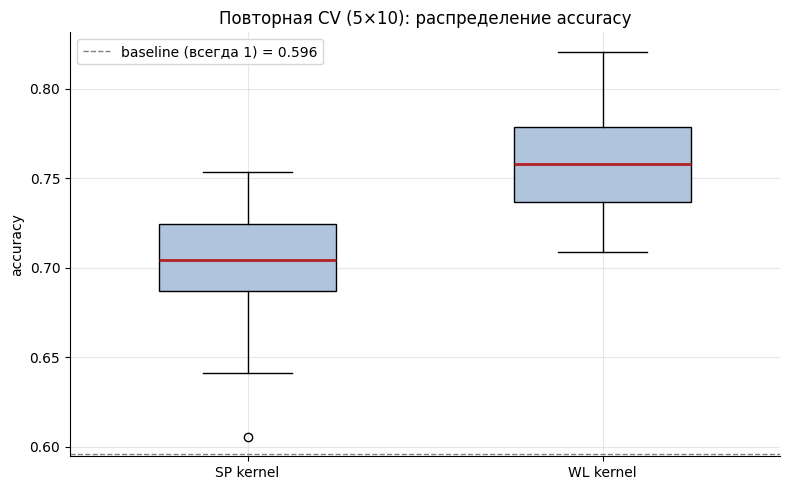

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([acc_sp, acc_wl], labels=["SP kernel", "WL kernel"], widths=0.5,
           patch_artist=True,
           boxprops=dict(facecolor="lightsteelblue"),
           medianprops=dict(color="firebrick", lw=2))
ax.axhline(y.mean(), color="gray", ls="--", lw=1, label=f"baseline (всегда 1) = {y.mean():.3f}")
ax.set_ylabel("accuracy"); ax.set_title("Повторная CV (5×10): распределение accuracy")
ax.legend()
plt.tight_layout(); plt.show()

WL целиком лежит выше яSP, и этот отрыв больше, чем обычный разброс точности между прогонами. Значит, выигрыш WL — не везение на одном разбиении, а устойчивый результат. При этом оба ядра имеют лучшую точность чем 60%(это важно тк из за смещения выборки выбирать класс 1 имело 60% точности)

## Выводы

на PROTEINS WL дает заметно лучший результат чем SP их получили и провалидировали

графы белков довольно крупные и, главное, у их вершин есть
полезные метки (тип элемента структуры). WL эти метки использует и улавливает сруктуру
укладки белка, а SP — только расстояния, поэтому ловит меньше.
